# LLM Agreement Validation

Checks internal consistency of the LLM scoring, before treating any of it as final. Two parts:

1. **DPM (Axis A) vs. subcategories (Axis B) alignment** -- Axis B's `blame_attribution`/`problem_identification` (under diagnostic), `solutions`/`tactics` (under prognostic), and `rationale`/`call_to_action` (under motivational) are scored via a completely separate LLM call from Axis A, with its own prompt and no mention of DPM at all (Project_Proposal.md §6.3.1: "parallel axes, not a hierarchy" -- separate calls per axis specifically to avoid the model just copying a label across axes). If the LLM's judgment is doing real, consistent work rather than noise, a post rated high on `diagnostic` should independently tend to score high on `blame_attribution`/`problem_identification` too -- **convergent validity** -- and more so than on the *other* four subcategories it has no reason to relate to -- **discriminant validity**. Neither is guaranteed just because the categories are conceptually related; the model was never told they were.
2. **Human vs. LLM agreement** -- stubbed for now, filled in once the ~50-post hand-coded validation sample exists.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import plot_style

plot_style.set_style()


## 1) DPM vs. Subcategory Alignment

### Config

In [2]:
DPM_SCORES_PATH = Path("../data/llm_scores/axis_a_dpm_de.csv")
DPM_CONCEPTS = ["diagnostic", "prognostic", "motivational"]

SUBCAT_SCORES_PATH = Path("../data/llm_scores/axis_b_dpm_subcategories_de.csv")
SUBCAT_CONCEPTS = ["blame_attribution", "problem_identification", "solutions", "tactics", "rationale", "call_to_action"]

# Which subcategories Axis B is theoretically nested under which Axis A concept
# (Mendelsohn et al., Table 2 -- see concepts/axis_b_dpm_subcategories_de.json) -- this mapping
# is ONLY used below to highlight expected-vs-unexpected pairs in the results; it plays no part
# in how either axis was scored.
EXPECTED_PARENT = {
    "blame_attribution": "diagnostic",
    "problem_identification": "diagnostic",
    "solutions": "prognostic",
    "tactics": "prognostic",
    "rationale": "motivational",
    "call_to_action": "motivational",
}


### Load and Debias Both Axes

Averages across orderings first if either run was counterbalanced (`n_orderings > 1`) -- a no-op if it was a single-ordering run, so this works unchanged either way.

In [3]:
def load_debiased(path: Path, concepts: list[str]) -> pd.DataFrame:
    scores = pd.read_csv(path, dtype={"text_id": str})
    n_orderings = scores["ordering_id"].nunique()
    print(f"{path.name}: {len(scores)} rows -- {scores['text_id'].nunique()} posts x {n_orderings} ordering(s)")
    return scores.groupby("text_id")[concepts].mean()


dpm_scores = load_debiased(DPM_SCORES_PATH, DPM_CONCEPTS)
subcat_scores = load_debiased(SUBCAT_SCORES_PATH, SUBCAT_CONCEPTS)

merged = dpm_scores.join(subcat_scores, how="inner")
print(f"\n{len(merged)} posts scored on both axes")
merged.head()


axis_a_dpm_de.csv: 4114 rows -- 4114 posts x 1 ordering(s)
axis_b_dpm_subcategories_de.csv: 4114 rows -- 4114 posts x 1 ordering(s)

4114 posts scored on both axes


,diagnostic,prognostic,motivational,blame_attribution,problem_identification,solutions,tactics,rationale,call_to_action
text_id,,,,,,,,,
1000164198627088,2.0,2.0,4.0,0.0,2.0,1.0,3.0,2.0,4.0
1000346171937094,0.0,0.0,3.0,0.0,1.0,0.0,2.0,0.0,3.0
1000583702759923,4.0,3.0,4.0,4.0,3.0,1.0,4.0,2.0,4.0
1001643848486680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0
1001705045323585,0.0,1.0,4.0,0.0,1.0,1.0,3.0,1.0,4.0


### Correlation Matrix: DPM x Subcategories

Full 3x6 Pearson correlation between every DPM concept and every subcategory -- not just the theoretically-expected pairs, so the off-diagonal (unexpected) pairs are visible too.

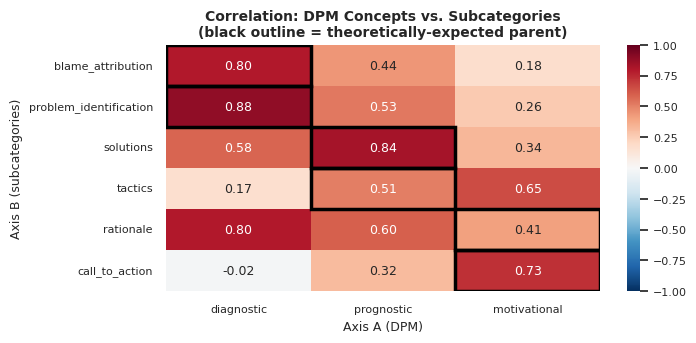

In [4]:
corr_matrix = pd.DataFrame(
    {dpm_concept: {subcat: merged[dpm_concept].corr(merged[subcat]) for subcat in SUBCAT_CONCEPTS} for dpm_concept in DPM_CONCEPTS}
)

fig, ax = plt.subplots(figsize=plot_style.FIGSIZE_WIDE)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)

# Outline each subcategory's theoretically-expected parent cell -- makes the read-out a single
# glance: is the darkest/reddest cell in each row actually inside its outline?
for row_i, subcat in enumerate(SUBCAT_CONCEPTS):
    col_i = DPM_CONCEPTS.index(EXPECTED_PARENT[subcat])
    ax.add_patch(plt.Rectangle((col_i, row_i), 1, 1, fill=False, edgecolor="black", linewidth=2.5))

ax.set_title("Correlation: DPM Concepts vs. Subcategories\n(black outline = theoretically-expected parent)")
ax.set_xlabel("Axis A (DPM)")
ax.set_ylabel("Axis B (subcategories)")
plot_style.savefig(fig, "FFF/dpm_subcategory_correlation_matrix")
plt.show()

### Convergent vs. Discriminant Validity: Own-Parent vs. Other DPM Concepts

For each subcategory, its correlation with its theoretically-expected DPM parent vs. the other two DPM concepts it has no expected relationship to. **Convergent validity** holds if `own_parent_corr` is reasonably high. Two versions of **discriminant validity**:
- `discriminates_lenient` -- own-parent correlation beats the *average* of the other two. Can pass even if one specific off-target concept individually outscores the true parent, as long as the other off-target concept is weak enough to pull the average back down.
- `discriminates_strict` -- own-parent correlation beats the *highest* of the other two, individually. This is the one that actually answers "does this subcategory ever look more like the wrong DPM concept than its own?"

In [5]:
rows = []
for subcat in SUBCAT_CONCEPTS:
    parent = EXPECTED_PARENT[subcat]
    others = [c for c in DPM_CONCEPTS if c != parent]
    other_corrs = corr_matrix.loc[subcat, others]
    rows.append({
        "subcategory": subcat,
        "expected_parent": parent,
        "own_parent_corr": corr_matrix.loc[subcat, parent],
        "other_parents_mean_corr": other_corrs.mean(),
        "other_parents_max_corr": other_corrs.max(),
        "strongest_other_parent": other_corrs.idxmax(),
    })

validity_summary = pd.DataFrame(rows).set_index("subcategory")
validity_summary["discriminates_lenient"] = validity_summary["own_parent_corr"] > validity_summary["other_parents_mean_corr"]
validity_summary["discriminates_strict"] = validity_summary["own_parent_corr"] > validity_summary["other_parents_max_corr"]
validity_summary


,expected_parent,own_parent_corr,other_parents_mean_corr,other_parents_max_corr,strongest_other_parent,discriminates_lenient,discriminates_strict
subcategory,,,,,,,
blame_attribution,diagnostic,0.800406,0.311439,0.444335,prognostic,True,True
problem_identification,diagnostic,0.884957,0.394696,0.525695,prognostic,True,True
solutions,prognostic,0.835728,0.458273,0.580748,diagnostic,True,True
tactics,prognostic,0.510689,0.410608,0.652150,motivational,True,False
rationale,motivational,0.411618,0.701548,0.802362,diagnostic,False,False
call_to_action,motivational,0.727591,0.148939,0.319018,prognostic,True,True


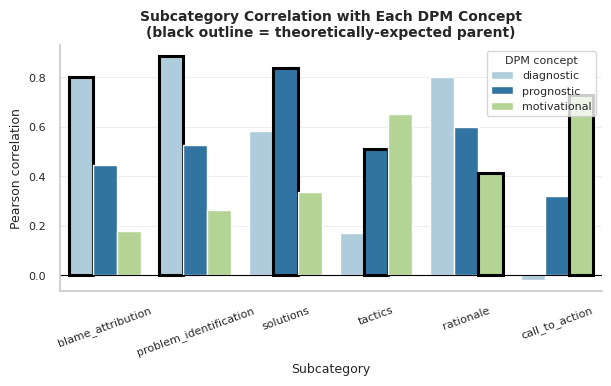

In [6]:
plot_df = (
    corr_matrix.loc[SUBCAT_CONCEPTS, DPM_CONCEPTS]
    .reset_index().rename(columns={"index": "subcategory"})
    .melt(id_vars="subcategory", var_name="dpm_concept", value_name="correlation")
)

fig, ax = plt.subplots(figsize=plot_style.FIGSIZE_WIDE)
sns.barplot(data=plot_df, x="subcategory", y="correlation", hue="dpm_concept",
            order=SUBCAT_CONCEPTS, hue_order=DPM_CONCEPTS, ax=ax)
ax.axhline(0, color="black", linewidth=0.8)

# Outline the expected-parent bar within each group -- "is the tallest bar the outlined one?"
# is then a one-glance read of discriminant validity, rather than needing the table above.
for container, dpm_concept in zip(ax.containers, DPM_CONCEPTS):
    for patch, subcat in zip(container, SUBCAT_CONCEPTS):
        if EXPECTED_PARENT[subcat] == dpm_concept:
            patch.set_edgecolor("black")
            patch.set_linewidth(2.2)

ax.set_title("Subcategory Correlation with Each DPM Concept\n(black outline = theoretically-expected parent)")
ax.set_xlabel("Subcategory")
ax.set_ylabel("Pearson correlation")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="DPM concept")
plot_style.savefig(fig, "FFF/dpm_subcategory_discriminant_validity")
plt.show()


### Verdict

**4 of 6 subcategories discriminate cleanly** (`discriminates_strict = True` -- own-parent correlation beats *both* other DPM concepts individually, not just their average): `blame_attribution` (0.80 vs. 0.44 / 0.18), `problem_identification` (0.89 vs. 0.53 / 0.26), `solutions` (0.84 vs. 0.58 / 0.34), and `call_to_action` (0.73 vs. 0.32 / -0.02 -- essentially no relationship to diagnostic at all). Two independently-worded, independently-run LLM calls agreeing this consistently, on constructs the model was never told were related, is solid convergent *and* discriminant validity evidence for four of the six subcategories.

**2 subcategories -- `rationale` and `tactics` -- correlate more strongly with a different DPM concept than their theoretical parent:**
- `rationale` (parent: `motivational`, r = 0.41) correlates far more strongly with `diagnostic` (r = 0.80, its highest correlation by a wide margin) and moderately with `prognostic` (r = 0.60). Its own parent is actually its *weakest* of the three correlations.
- `tactics` (parent: `prognostic`, r = 0.51) correlates more strongly with `motivational` (r = 0.65) -- about 14 percentage points higher.

Both look like reasonable mistakes rather than arbitrary ones, and there's a plausible theoretical story for each:
- A **rationale** meant to mobilize people is, in practice, very often *also* a description of the problem itself -- urgency framing ("the situation is dire") tends to double as diagnosis. The two functions may be harder to keep apart in short-form Instagram captions than Mendelsohn et al.'s coding scheme, developed for longer text, assumes.
- A **tactic** (a concrete action format -- a strike, a petition) is frequently stated *as* a call to participate, blurring into motivational language even though Mendelsohn et al. class it under prognostic ("what should be done").

Since axis A and axis B were scored via separate LLM calls with no shared vocabulary or explicit hierarchy in either prompt, this pattern is unlikely to be a scoring artifact -- it more plausibly reflects a genuine ambiguity in how these two subcategories manifest in FFF's actual post text. Worth reporting as a limitation of the Mendelsohn subcategory scheme's fit to this corpus, not as an LLM scoring failure.

## 2) Human vs. LLM Agreement -- STUB

Not runnable yet -- fill in once the ~50-post hand-coded validation sample (DPM, subcategory, master frame, inequality arena) exists. Sketch of what this section should do once that data is available:

- Load the hand-coded CSV (post id + human ratings per concept, same concept names as the LLM output).
- Join against the corresponding debiased LLM scores (same `load_debiased()` pattern as above).
- Per concept: ICC(2,1) between human and LLM ratings (`src/reliability.icc_2_1`, same function used for the ordering-effect checks in `01_robustness_checks.ipynb` -- here treating "human" and "LLM" as the two "raters" instead of two orderings), plus a scatter plot of human vs. LLM rating per post with the diagonal for reference.
- Worth deciding in advance: is systematic over/under-estimation (LLM consistently rates higher/lower than the human, even with high correlation) treated as a calibration issue to correct for, or as a validity problem to report as-is?